# Strategy Recommendations

**Docker image**: `ml4t`

This notebook makes the final call: which case studies survive the full
pipeline from signal detection through holdout validation, and which
fail — and why?

Every gate outcome and metric here is derived from the data produced by
NB01–NB05; the HTM cost-cascade figures (which reproduce
htm_cost_sensitivity.parquet) and the S&P 500 Options cost handling are the
only hardcoded elements.

**Learning Objectives**:
- Trace the stage attrition funnel through the pipeline gates for each of 9 case studies
- Classify failures into signal, implementation, and evidence-quality buckets
- Identify structural features that predict pipeline survival

**Book Reference**: Chapter 20, Section 20.9 (Next steps after the first
research iteration), whose Figure 20.18 is this attrition funnel

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb). The holdout rows it reads come from each case study's own holdout notebooks, not from this chapter.

In [1]:
"""Ch20 NB06 — Final recommendations derived from pipeline data."""

import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import FancyBboxPatch, Patch

from utils.paths import get_chapter_dir
from utils.style import COLORS, add_message_title, show_with_alt

In [2]:
MAX_SYMBOLS = 0

In [3]:
OUTPUT_DIR = get_chapter_dir(20) / "output"

DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firms",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}
NASDAQ_ID = "nasdaq100_microstructure"

## 1. Load Pipeline Data

All data comes from NB01 (aggregate synthesis), which is also what writes
`holdout_results.parquet` read below.
We make no assumptions beyond what the data shows.

In [4]:
synthesis = json.load((OUTPUT_DIR / "all_synthesis.json").open())

# Registry-based holdout results (more current than synthesis JSON)
holdout_df = pl.read_parquet(OUTPUT_DIR / "holdout_results.parquet")
holdout_map = {row["cs_id"]: row for row in holdout_df.iter_rows(named=True)}

print(f"Loaded synthesis for {len(synthesis)} case studies")
print(f"Holdout results for {holdout_df.height} case studies")

missing_holdout = sorted(set(synthesis) - set(holdout_map))
if missing_holdout:
    print(
        "\nNo holdout row for: "
        + ", ".join(DISPLAY_NAMES.get(cs, cs) for cs in missing_holdout)
        + "\nEach is classified below as lacking holdout evidence rather than as having failed "
        "a gate. The two are different conclusions and the table keeps them apart."
    )

Loaded synthesis for 9 case studies
Holdout results for 8 case studies

No holdout row for: NASDAQ-100
Each is classified below as lacking holdout evidence rather than as having failed a gate. The two are different conclusions and the table keeps them apart.


## 2. Stage Attrition Funnel

The centerpiece of this analysis. We start with 9 case studies and
trace how many survive each pipeline gate. At each stage, we name
which case studies drop and why.

The gates are cumulative: a case study must pass all preceding gates
to be counted at the next stage. NB01's funnel (see the "Stage
Attrition Funnel" section in `01_aggregate_synthesis`) reports the
same gates with *independent* per-stage counts — useful for seeing
which gate is the largest filter, not which case studies survive end
to end. Per-stage independent counts in NB01 can therefore exceed the
cumulative count shown here.

In [5]:
# Build the attrition data from pipeline evidence
stages = []

# Gate 0: All case studies start
all_cs = list(synthesis.keys())
stages.append(("Start", set(all_cs)))

# Gate 1: Positive IC (best model family has IC > 0)
positive_ic = set()
for cs, data in synthesis.items():
    models = data["pipeline_summary"]["models"]
    best_ic = max((m.get("ic_mean") or 0) for m in models.values()) if models else 0
    if best_ic > 0:
        positive_ic.add(cs)
stages.append(("Positive IC", positive_ic))

**Gate 2 - positive validation Sharpe.** The gate reads the selected configuration's
validation ML Sharpe rather than the risk stage's baseline Sharpe. The latter is null for
case studies whose risk stage does not apply - sp500_options under hold-to-maturity, the
vectorized us_firm_characteristics path, and nasdaq before its ensemble cost and risk pass -
so reading it would drop them at the validation gate on a stage that does not apply to
them.

In [6]:
positive_val_sharpe = set()
for cs in positive_ic:
    bt = synthesis[cs]["pipeline_summary"].get("backtest", {})
    val_sr = bt.get("ml_sharpe")
    # Validation applies to every case study; drop only on a genuine
    # non-positive selection Sharpe (FX Pairs, val −0.004).
    if val_sr is None or val_sr > 0:
        positive_val_sharpe.add(cs)
stages.append(("Val Sharpe > 0", positive_val_sharpe))

**Gate 3 - transaction costs.** Net Sharpe has to stay positive at the case study's
actual cost level. A case study whose cost stage does not apply passes through rather than
being eliminated: sp500_options uses the option-native bid-ask accounting of §18.8 rather than
a basis-point sweep. A gate drops a case study only on a genuine negative outcome at a stage
that applies to it.

In [7]:
cost_surviving = set()
for cs in positive_val_sharpe:
    costs = synthesis[cs]["pipeline_summary"]["costs"]
    if costs.get("not_applicable_reason"):
        cost_surviving.add(cs)
        continue
    net_sr = costs.get("net_sharpe_at_actual")
    if costs.get("survives_costs") and net_sr is not None and net_sr > 0:
        cost_surviving.add(cs)
stages.append(("Cost Survival", cost_surviving))

# Gate 4: Holdout gate (holdout Sharpe > 0)
holdout_passing = set()
for cs in cost_surviving:
    ho = holdout_map.get(cs, {})
    ho_sharpe = ho.get("holdout_sharpe")
    if ho_sharpe is not None and ho_sharpe > 0:
        holdout_passing.add(cs)
stages.append(("Holdout SR > 0", holdout_passing))

**Gate 5 - the risk overlay leaves an edge, and the uncertainty evidence supports a
deployment-facing classification.** As with the cost gate, a case study whose risk stage does
not apply passes through rather than being eliminated: sp500_options because of its
hold-to-maturity expiration structure, and us_firm_characteristics because its vectorized path
has its portfolio overlays purged.

In [8]:
all_gates_pass = set()
for cs in holdout_passing:
    if cs == NASDAQ_ID:
        # The fixed configuration is positive on point estimate, but both corrected
        # validation and holdout intervals cross zero. Broad cost and risk grids
        # are also deferred to v3.1, so it cannot clear the evidence gate.
        continue
    risk = synthesis[cs]["pipeline_summary"].get("risk", {})
    if risk.get("not_applicable_reason"):
        all_gates_pass.add(cs)
        continue
    managed_sr = risk.get("managed_sharpe")
    if managed_sr is not None and managed_sr > 0:
        all_gates_pass.add(cs)
stages.append(("Evidence ready", all_gates_pass))

# Print the funnel
print("=== Stage Attrition Funnel ===\n")
for i, (name, passing) in enumerate(stages):
    dropped = stages[i - 1][1] - passing if i > 0 else set()
    dropped_names = [DISPLAY_NAMES.get(c, c) for c in sorted(dropped)]
    n = len(passing)
    bar = "█" * n + "░" * (9 - n)
    drop_str = f"  dropped: {', '.join(dropped_names)}" if dropped_names else ""
    print(f"  {name:20s} {bar} {n}/9{drop_str}")

=== Stage Attrition Funnel ===

  Start                █████████ 9/9
  Positive IC          █████████ 9/9
  Val Sharpe > 0       ████████░ 8/9  dropped: S&P 500 Options
  Cost Survival        ████████░ 8/9
  Holdout SR > 0       █████░░░░ 5/9  dropped: Crypto, NASDAQ-100, US Equities
  Evidence ready       █████░░░░ 5/9


### Stage Attrition Waterfall

This is the single most important figure in Ch20. It shows the
cumulative pipeline survival rate and names every dropout.

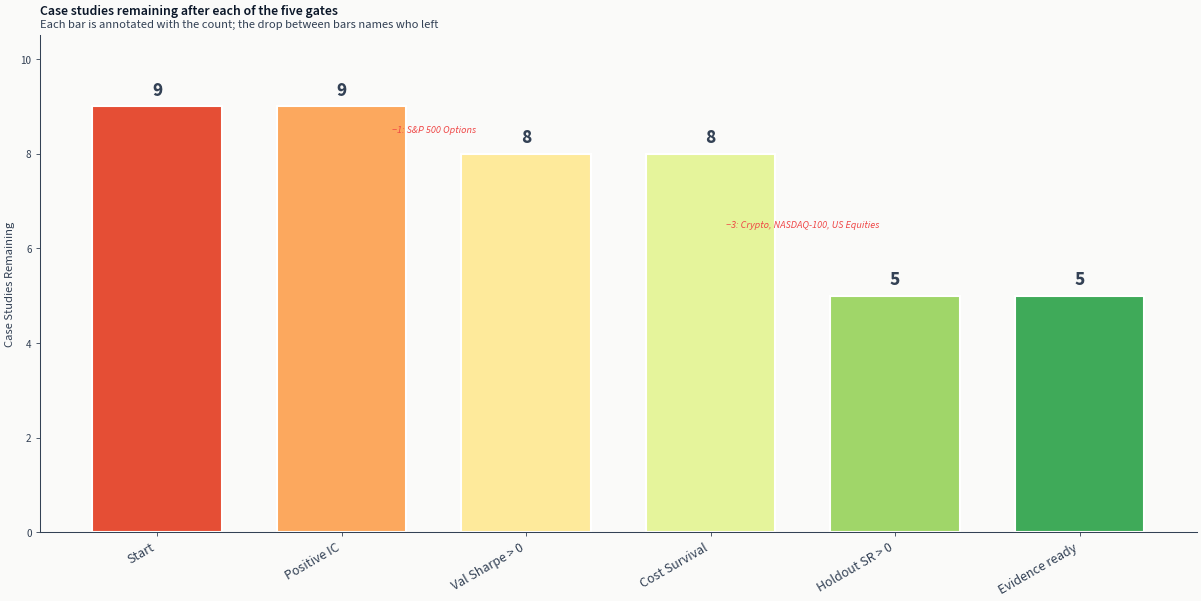

In [9]:
stage_names = [s[0] for s in stages]
stage_counts = [len(s[1]) for s in stages]

fig, ax = plt.subplots(figsize=(12, 6))

# Waterfall bars
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(stage_names)))
bars = ax.bar(
    range(len(stage_names)), stage_counts, color=colors, edgecolor="white", linewidth=1.5, width=0.7
)

# Annotate counts and dropouts
for i, (bar, count) in enumerate(zip(bars, stage_counts, strict=False)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=14,
    )

    if i > 0:
        dropped = stages[i - 1][1] - stages[i][1]
        if dropped:
            dropped_names = [DISPLAY_NAMES.get(c, c) for c in sorted(dropped)]
            delta = stage_counts[i - 1] - count
            # Show dropout annotation
            ax.annotate(
                f"−{delta}: {', '.join(dropped_names)}",
                xy=(i - 0.5, (stage_counts[i - 1] + count) / 2),
                fontsize=7.5,
                color=COLORS["negative"],
                ha="center",
                va="center",
                style="italic",
            )

ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Case Studies Remaining")
ax.set_ylim(0, 10.5)
ax.axhline(y=0, color=COLORS["neutral"], linewidth=0.5)
add_message_title(
    ax,
    "Case studies remaining after each of the five gates",
    subtitle="Each bar is annotated with the count; the drop between bars names who left",
)
show_with_alt(
    fig,
    "A bar per pipeline gate, left to right in pipeline order, each labelled with the number "
    "of case studies still passing at that point. The bars step down from left to right and "
    "never recover, and the gap between consecutive bars carries an italic note naming the "
    "case studies dropped there.",
)

The waterfall counts how many of the nine case studies remain after each
cumulative gate and names the ones that drop at each. The five gates ask
different questions of the same strategy, in pipeline order: whether the
prediction has a positive information coefficient, whether the selected
configuration's validation Sharpe is positive, whether it survives its cost
regime, whether its holdout Sharpe is positive, and whether the evidence
behind that holdout is strong enough to act on.

## 3. Exclusion Taxonomy

Every case study that fails the pipeline maps to at least one exclusion
type. We organize these into three parent buckets and assign them
**from the data**, not from hardcoded labels.

In [10]:
def classify_exclusions():
    """Classify each case study's pipeline failures into exclusion categories."""
    # Data-driven exclusion assignment
    exclusions: dict[str, list[dict]] = defaultdict(list)

    for cs, data in synthesis.items():
        display = DISPLAY_NAMES.get(cs, cs)
        models = data["pipeline_summary"]["models"]
        costs = data["pipeline_summary"]["costs"]
        risk = data["pipeline_summary"].get("risk", {})
        ho = holdout_map.get(cs, {})

        best_ic = max((m.get("ic_mean") or 0) for m in models.values()) if models else 0
        ho_sharpe = ho.get("holdout_sharpe")
        ho_ic = ho.get("holdout_ic")
        net_sr = costs.get("net_sharpe_at_actual")
        survives = costs.get("survives_costs", False)
        managed_sr = risk.get("managed_sharpe")
        worst_dd = risk.get("worst_drawdown_pct", 0)

        # Signal invalidity
        if best_ic <= 0:
            exclusions["No detectable signal"].append(
                {"cs": display, "detail": f"Best IC = {best_ic:.4f}"}
            )
        elif net_sr is not None and net_sr <= 0 and survives is False:
            exclusions["Insufficient edge after costs"].append(
                {"cs": display, "detail": f"IC = {best_ic:.4f} but net SR = {net_sr:.2f}"}
            )
        elif (
            best_ic > 0
            and net_sr is not None
            and net_sr > 0
            and ho_sharpe is not None
            and ho_sharpe <= 0
        ):
            # Had signal, had validation Sharpe, but holdout collapsed
            pass  # Will be caught by holdout_collapse below

        # Holdout collapse
        if ho_sharpe is not None and ho_sharpe <= 0 and cs in positive_val_sharpe:
            exclusions["Holdout collapse"].append(
                {"cs": display, "detail": f"Val SR → Holdout SR = {ho_sharpe:.2f}"}
            )
        elif ho_sharpe is None and cs in positive_val_sharpe:
            exclusions["Holdout not available"].append(
                {"cs": display, "detail": "Degenerate or missing holdout predictions"}
            )

        # Implementation infeasibility
        if cs == "sp500_options":
            exclusions["Net-negative under realistic costs"].append(
                {
                    "cs": display,
                    "detail": "HTM cost cascade max Sharpe = -0.28 at 20% half-spread fraction; net Sharpe negative across the full cascade (-0.47 at 50%, -0.72 at 100%)",
                }
            )

        if abs(worst_dd) > 50:
            exclusions["Unacceptable drawdown"].append(
                {"cs": display, "detail": f"Max DD = {worst_dd:.0f}%"}
            )

        # A holdout interval spanning zero says the window cannot tell this strategy from
        # one with no edge, which is not the same as failing a gate. Read from the row, so it
        # names whichever case studies it is true of rather than one fixed in advance.
        if not ho:
            exclusions["No holdout evidence"].append(
                {"cs": display, "detail": "No holdout row in the registry"}
            )
        elif (
            ho.get("holdout_sharpe_ci_lo") is not None
            and ho.get("holdout_sharpe_ci_hi") is not None
            and ho["holdout_sharpe_ci_lo"] < 0 < ho["holdout_sharpe_ci_hi"]
        ):
            exclusions["Statistically unresolved"].append(
                {
                    "cs": display,
                    "detail": (
                        f"Holdout Sharpe {ho['holdout_sharpe']:+.3f}, interval "
                        f"[{ho['holdout_sharpe_ci_lo']:+.3f}, "
                        f"{ho['holdout_sharpe_ci_hi']:+.3f}] spans zero"
                    ),
                }
            )
    return exclusions

In [11]:
exclusions = classify_exclusions()

# Group into parent buckets
BUCKETS = {
    "Signal Invalidity": [
        "No detectable signal",
        "Insufficient edge after costs",
        "Positive IC but no stable Sharpe",
        "Cadence-horizon mismatch",
    ],
    "Implementation Infeasibility": [
        "Net-negative under realistic costs",
        "Unacceptable drawdown",
    ],
    "Evidence-Quality Failure": [
        "Holdout collapse",
        "Holdout not available",
        "Unreproducible model",
        "Statistically unresolved",
    ],
}

print("=== Exclusion Taxonomy ===\n")
for bucket, types in BUCKETS.items():
    active_types = [(t, exclusions[t]) for t in types if exclusions[t]]
    if not active_types:
        continue
    print(f"  {bucket}")
    for excl_type, cases in active_types:
        print(f"    • {excl_type}")
        for case in cases:
            print(f"      – {case['cs']}: {case['detail']}")
    print()

=== Exclusion Taxonomy ===

  Implementation Infeasibility
    • Net-negative under realistic costs
      – S&P 500 Options: HTM cost cascade max Sharpe = -0.28 at 20% half-spread fraction; net Sharpe negative across the full cascade (-0.47 at 50%, -0.72 at 100%)

  Evidence-Quality Failure
    • Holdout collapse
      – Crypto: Val SR → Holdout SR = -0.83
      – US Equities: Val SR → Holdout SR = -2.29
    • Holdout not available
      – NASDAQ-100: Degenerate or missing holdout predictions
    • Statistically unresolved
      – Crypto: Holdout Sharpe -0.832, interval [-2.185, +0.394] spans zero
      – S&P 500 Eq+Opt: Holdout Sharpe +1.317, interval [-0.430, +3.056] spans zero
      – FX Pairs: Holdout Sharpe +0.434, interval [-0.867, +1.694] spans zero
      – CME Futures: Holdout Sharpe +0.324, interval [-1.024, +1.691] spans zero
      – S&P 500 Options: Holdout Sharpe +0.588, interval [-1.275, +2.997] spans zero



The three-bucket organization makes the taxonomy easier to remember
and act on:

- **Signal invalidity** means the prediction problem itself doesn't
  work — no amount of better implementation will help.
- **Implementation infeasibility** means the signal exists but
  practical constraints (costs, drawdowns) prevent deployment.
- **Evidence-quality failure** means we can't trust the results —
  either the holdout invalidated the signal, or the evaluation
  infrastructure has gaps.

The taxonomy helps diagnose *why* a case study failed, not grade it.
Each failure mode points to a different second-iteration response.

## 4. Pipeline Evidence Summary

For each case study we report the factual per-gate evidence the pipeline
produced — positive validation IC, survival of the cost sweep, positive
holdout Sharpe, positive risk-managed Sharpe, and holdout decay under
fifty percent. These are observations rather than categorical deployment
labels; readers who want to weigh the evidence differently have all the
numbers in one place.

In [12]:
def build_evidence_profile():
    """Per-case-study factual evidence across the pipeline gates.

    Reports five gate-level booleans (positive IC, survives costs, positive
    holdout Sharpe, positive risk-managed Sharpe, holdout decay < 50%) plus
    the underlying numbers. No categorical "outcome" label is assigned —
    the evidence is reported as observations.
    """
    rows = []
    for cs, data in synthesis.items():
        display = DISPLAY_NAMES.get(cs, cs)
        models = data["pipeline_summary"]["models"]
        costs = data["pipeline_summary"]["costs"]
        risk = data["pipeline_summary"].get("risk", {})
        ho = holdout_map.get(cs, {})

        best_ic = max((m.get("ic_mean") or 0) for m in models.values()) if models else 0
        ho_sharpe = ho.get("holdout_sharpe")
        net_sr = costs.get("net_sharpe_at_actual")
        managed_sr = risk.get("managed_sharpe")

        positive_ic = best_ic > 0
        cost_na = bool(costs.get("not_applicable_reason"))
        risk_na = bool(risk.get("not_applicable_reason"))
        survives_costs = bool(costs.get("survives_costs", False))
        positive_holdout = ho_sharpe is not None and ho_sharpe > 0
        positive_managed = managed_sr is not None and managed_sr > 0

        backtest = data["pipeline_summary"].get("backtest", {})
        val_sharpe = backtest.get("ml_sharpe") or 0
        if val_sharpe > 0 and ho_sharpe is not None:
            holdout_decay = (val_sharpe - ho_sharpe) / val_sharpe
        else:
            holdout_decay = None
        modest_decay = holdout_decay is not None and holdout_decay < 0.50
        evidence_resolved = cs != NASDAQ_ID

        # Gate tally as passed/applicable. A stage that does not apply leaves both the
        # numerator and the denominator rather than counting as a failure, so no case study
        # is penalized for a stage its canonical strategy never runs.
        gate_flags = [
            (True, positive_ic),
            (not cost_na, survives_costs),
            (True, positive_holdout),
            (not risk_na, positive_managed),
            (True, modest_decay),
            (True, evidence_resolved),
        ]
        gates_passed = sum(1 for appl, passed in gate_flags if appl and passed)
        gates_applicable = sum(1 for appl, _ in gate_flags if appl)

        cs_exclusions = []
        for excl_type, cases in exclusions.items():
            for case in cases:
                if case["cs"] == display:
                    cs_exclusions.append(excl_type)

        rows.append(
            {
                "case_study": display,
                "gates_passed": gates_passed,
                "gates_applicable": gates_applicable,
                "positive_ic": positive_ic,
                "survives_costs": survives_costs,
                "positive_holdout": positive_holdout,
                "positive_managed": positive_managed,
                "modest_decay": modest_decay,
                "evidence_resolved": evidence_resolved,
                "best_ic": round(best_ic, 4),
                "holdout_sharpe": round(ho_sharpe, 2) if ho_sharpe is not None else None,
                "net_sharpe": round(net_sr, 2) if net_sr is not None else None,
                "managed_sharpe": round(managed_sr, 2) if managed_sr is not None else None,
                "holdout_decay": round(holdout_decay, 2) if holdout_decay is not None else None,
                "exclusions": "; ".join(cs_exclusions) if cs_exclusions else "—",
                "top_family": ho.get("family", "—") if ho else "—",
            }
        )
    return pl.DataFrame(rows).sort(["gates_passed", "best_ic"], descending=[True, True])

In [13]:
evidence_df = build_evidence_profile()


def _fmt(v, spec=".2f"):
    return format(v, spec) if v is not None else "n/a"


print("=== Pipeline Evidence Summary ===\n")
print(
    f"{'Case Study':22s} {'Gates':>6s}  {'Best IC':>8s}  {'HO SR':>7s}  {'Net SR':>7s}  {'Mgd SR':>7s}  {'Decay':>6s}  Exclusions"
)
print("─" * 110)
for row in evidence_df.iter_rows(named=True):
    gates = f"{row['gates_passed']}/{row['gates_applicable']}"
    ic = f"{row['best_ic']:+.4f}"
    decay = f"{row['holdout_decay']:.0%}" if row["holdout_decay"] is not None else "n/a"
    print(
        f"{row['case_study']:22s} {gates:>6s}  {ic:>8s}  "
        f"{_fmt(row['holdout_sharpe']):>7s}  {_fmt(row['net_sharpe']):>7s}  "
        f"{_fmt(row['managed_sharpe']):>7s}  {decay:>6s}  {row['exclusions']}"
    )

# Display as table
evidence_df.select(
    "case_study",
    "gates_passed",
    "top_family",
    "best_ic",
    "holdout_sharpe",
    "net_sharpe",
    "managed_sharpe",
    "holdout_decay",
    "exclusions",
)

=== Pipeline Evidence Summary ===

Case Study              Gates   Best IC    HO SR   Net SR   Mgd SR   Decay  Exclusions
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
ETFs                      6/6   +0.0882     1.31     0.84     1.02    -77%  —
FX Pairs                  6/6   +0.0150     0.43     0.31     0.41   -100%  Statistically unresolved
S&P 500 Eq+Opt            6/6   +0.0112     1.32     2.59     2.61     18%  Statistically unresolved
US Firms                  5/5   +0.0836     2.74     3.57      n/a     23%  —
CME Futures               5/6   +0.0443     0.32     0.98     1.10     67%  Statistically unresolved
Crypto                    4/6   +0.0344    -0.83     1.92     1.67    153%  Holdout collapse; Statistically unresolved
US Equities               4/6   +0.0343    -2.29     0.52     1.05    318%  Holdout collapse
S&P 500 Options           3/4   +0.0282     0.59      n/a      n/a     n/a  Statistically unreso

case_study,gates_passed,top_family,best_ic,holdout_sharpe,net_sharpe,managed_sharpe,holdout_decay,exclusions
str,i64,str,f64,f64,f64,f64,f64,str
"""ETFs""",6,"""linear""",0.0882,1.31,0.84,1.02,-0.77,"""—"""
"""FX Pairs""",6,"""linear""",0.015,0.43,0.31,0.41,-1.0,"""Statistically unresolved"""
"""S&P 500 Eq+Opt""",6,"""gbm""",0.0112,1.32,2.59,2.61,0.18,"""Statistically unresolved"""
"""US Firms""",5,"""gbm""",0.0836,2.74,3.57,null,0.23,"""—"""
"""CME Futures""",5,"""latent_factors""",0.0443,0.32,0.98,1.1,0.67,"""Statistically unresolved"""
"""Crypto""",4,"""linear""",0.0344,-0.83,1.92,1.67,1.53,"""Holdout collapse; Statisticall…"
"""US Equities""",4,"""gbm""",0.0343,-2.29,0.52,1.05,3.18,"""Holdout collapse"""
"""S&P 500 Options""",3,"""gbm""",0.0282,0.59,null,null,null,"""Statistically unresolved; Net-…"
"""NASDAQ-100""",1,"""—""",0.0091,null,null,null,null,"""Holdout not available; No hold…"


## 5. Structural Features and Gate Passage

The attrition funnel shows *which* gate a case study was eliminated at.
This section asks: what structural features correlate with passing
every pipeline gate?

In [14]:
# Build structural features for each CS
structural_rows = []
for cs, data in synthesis.items():
    meta = data["meta"]
    models = data["pipeline_summary"]["models"]
    costs = data["pipeline_summary"]["costs"]
    ho = holdout_map.get(cs, {})

    best_ic = max((m.get("ic_mean") or 0) for m in models.values()) if models else 0
    ho_sharpe = ho.get("holdout_sharpe")

    passes_all_gates = (
        ho_sharpe is not None
        and ho_sharpe > 0
        and costs.get("survives_costs", False)
        and cs != "sp500_options"  # Known evidence issue: spread overwhelms signal
        and cs != NASDAQ_ID  # Fixed-configuration intervals cross zero; broad grids deferred
    )

    structural_rows.append(
        {
            "case_study": DISPLAY_NAMES.get(cs, cs),
            "asset_class": meta.get("asset_class", "unknown"),
            "frequency": meta.get("frequency", "unknown"),
            "universe_size": meta.get("universe_size", 0),
            "best_val_ic": best_ic,
            "holdout_sharpe": ho_sharpe,
            "passes_all_gates": passes_all_gates,
            "top_family": ho.get("family", "unknown") if ho else "unknown",
            "cost_bps": costs.get("actual_bps", 0),
        }
    )

struct_df = pl.DataFrame(structural_rows)

In [15]:
# Analysis: what structural features correlate with gate passage?
full_pass = struct_df.filter(pl.col("passes_all_gates"))
gate_miss = struct_df.filter(~pl.col("passes_all_gates"))

print("=== Structural Analysis: Full-Gate Pass vs Gate Miss ===\n")
print(f"All gates pass ({full_pass.height}): {', '.join(full_pass['case_study'].to_list())}")
print(f"At least one miss ({gate_miss.height}): {', '.join(gate_miss['case_study'].to_list())}")

if full_pass.height > 0 and gate_miss.height > 0:
    pass_ic = full_pass["best_val_ic"].mean()
    miss_ic = gate_miss["best_val_ic"].mean()
    print(f"\nMean validation IC — full pass: {pass_ic:.4f}, gate miss: {miss_ic:.4f}")

    # Frequency distribution
    print("\nFrequency distribution:")
    for freq in struct_df["frequency"].unique().sort().to_list():
        n_pass = full_pass.filter(pl.col("frequency") == freq).height
        n_miss = gate_miss.filter(pl.col("frequency") == freq).height
        print(f"  {freq:12s}: {n_pass} full-pass, {n_miss} gate-miss")

    # Top-family distribution
    print("\nRank-1 model family:")
    for fam in struct_df["top_family"].unique().sort().to_list():
        n_pass = full_pass.filter(pl.col("top_family") == fam).height
        n_miss = gate_miss.filter(pl.col("top_family") == fam).height
        total = n_pass + n_miss
        if total > 0:
            print(f"  {fam:18s}: {n_pass}/{total} full-pass ({100 * n_pass / total:.0f}%)")

=== Structural Analysis: Full-Gate Pass vs Gate Miss ===

All gates pass (5): ETFs, S&P 500 Eq+Opt, US Firms, FX Pairs, CME Futures
At least one miss (3): Crypto, NASDAQ-100, US Equities

Mean validation IC — full pass: 0.0485, gate miss: 0.0259

Frequency distribution:
  15min       : 0 full-pass, 1 gate-miss
  8h          : 0 full-pass, 1 gate-miss
  daily       : 4 full-pass, 1 gate-miss
  monthly     : 1 full-pass, 0 gate-miss

Rank-1 model family:
  gbm               : 2/3 full-pass (67%)
  latent_factors    : 1/1 full-pass (100%)
  linear            : 2/3 full-pass (67%)
  unknown           : 0/1 full-pass (0%)


The comparison splits the nine case studies into those that clear every gate
and those that miss at least one, and reports three readings of that split:
mean validation IC on each side, and the pass-against-miss counts broken out
by rebalancing frequency and by selected model family. The split is binary, so
a case study's position says that it missed somewhere and not how far it got;
the waterfall above is where the gate a case study left at is read. The
question the three readings ask is whether clearing every gate tracks the
strength of the signal, a structural property of the market, or the choice of
model.

Where a case study's holdout confidence interval spans zero, the exclusion
table above prints the interval beside the point estimate. An interval that
wide says the holdout window cannot distinguish the strategy from one with no
edge, which is a different statement from having found it wanting.

## 6. Evidence Snapshot

Compact per-case-study summary of the end-of-pipeline numbers, sorted
by the count of gates passed (descending), then by best IC.

In [16]:
print("=== Evidence Snapshot ===\n")
print(
    f"{'Case Study':25s} {'Gates':>6s} {'Top Family':12s} {'Managed SR':>10s} {'Net SR':>10s} {'HO SR':>10s}  Primary Exclusion"
)
print("─" * 110)

for row in evidence_df.iter_rows(named=True):
    ho_str = f"{row['holdout_sharpe']:.2f}" if row["holdout_sharpe"] is not None else "n/a"
    net_str = f"{row['net_sharpe']:.2f}" if row["net_sharpe"] is not None else "n/a"
    managed_str = f"{row['managed_sharpe']:.2f}" if row["managed_sharpe"] is not None else "n/a"
    gates = f"{row['gates_passed']}/{row['gates_applicable']}"
    excl = row["exclusions"][:40] if row["exclusions"] != "—" else "—"
    print(
        f"{row['case_study']:25s} {gates:>6s} {row['top_family']:12s} {managed_str:>10s} {net_str:>10s} {ho_str:>10s}  {excl}"
    )

=== Evidence Snapshot ===

Case Study                 Gates Top Family   Managed SR     Net SR      HO SR  Primary Exclusion
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
ETFs                         6/6 linear             1.02       0.84       1.31  —
FX Pairs                     6/6 linear             0.41       0.31       0.43  Statistically unresolved
S&P 500 Eq+Opt               6/6 gbm                2.61       2.59       1.32  Statistically unresolved
US Firms                     5/5 gbm                 n/a       3.57       2.74  —
CME Futures                  5/6 latent_factors       1.10       0.98       0.32  Statistically unresolved
Crypto                       4/6 linear             1.67       1.92      -0.83  Holdout collapse; Statistically unresolv
US Equities                  4/6 gbm                1.05       0.52      -2.29  Holdout collapse
S&P 500 Options              3/4 gbm                 n/a        n

## 7. Ensembles: A Chapter-End Note

A natural follow-on question is whether equal-weight blending of the
top-three configurations per case study would tighten cross-fold
stability at the cost of a small reduction in peak Sharpe. The
experiment was carried out outside this notebook (on the per-fold
return series, not on the per-fold Sharpe summaries that the registry
stores for the selected configuration in most case studies this iteration).
The finding is documented in the chapter prose.

The result is not registered, since this is not the iteration in
which we are scoring ensembles against single-model selected
configurations. The "next iteration" list at the end of this section
carries it.

NASDAQ-100 is the bounded exception in this release: its ensemble was fixed
before holdout scoring as diversification under overlapping validation
uncertainty. The corrected linear holdout is a comparator only and
cannot be used to reselect the selected configuration or describe the ensemble as an ex-post
rescue.

## Key Takeaways

1. **The funnel is the story**: starting from 9 case studies, the
   pipeline progressively narrows the set of case studies that pass
   each gate. Each gate drops cases for a different reason.

2. **Signal is necessary but not sufficient**: a positive information
   coefficient establishes that the prediction problem has structure.
   Whether that structure survives costs, the holdout window and the
   evidence checks is what the later gates ask, and each asks it
   independently.

3. **Costs are the great equalizer**: the cost gate a strategy has to clear
   is set by the instrument it trades, not by the strength of its signal.
   The edge-to-cost ratio, not IC alone, is what that gate tests.

4. **Failure modes are distinct**: the exclusion taxonomy identifies
   three structural failure categories — signal invalidity,
   implementation infeasibility, and evidence-quality failure.
   Each points to a different second-iteration response.

5. **Evidence quality is not the headline Sharpe**: a managed Sharpe is read
   alongside the cost environment it was earned in and the holdout that
   followed it. The evidence snapshot above prints all three for every case
   study, so a Sharpe paired with a fatal cost cascade or with a reversing
   holdout is visible as a pair rather than as a single number.

6. **The pipeline matters more than any single model**: the full
   journey from data to holdout determines the evidence a case study
   produces. Rank in prediction (Ch11-15) and gates passed (Ch16-20)
   are reported separately above for that reason.

## What Comes Next

These nine case studies used publicly available, low-frequency market
data with starter model configurations. The funnel above reports what the
pipeline produced at each gate. The chapter's claim is methodological: this is the
pipeline a practitioner should run to find out whether a candidate
strategy works, not a set of deployable strategies.

The next-iteration handles inside the same workflow:

- **Label refinement**: horizon choice, winsorization and the
  classification-against-regression framing are the label axes the
  `model_analysis` notebooks compare per case study. Systematic label
  search across them is the natural next sweep.
- **Feature engineering**: the case studies share generic financial
  features. Domain-specific features (order flow for NQ100, carry
  dynamics for CME, funding structure for crypto) are the natural next
  addition to test against the same triage and holdout protocol.
- **Model tuning**: hyperparameter grids are deliberately modest in
  this iteration. Focused tuning with larger search budgets, on whichever
  families survive the holdout gate, is the next sweep.
- **Ensemble construction**: the `model_analysis` notebooks report
  inter-family prediction correlation per case study; a simple average
  ensemble is a candidate for variance reduction at constant mean IC.
- **Strategy design**: this iteration tests basic long-short with a
  few allocation methods. Sector constraints, regime conditioning,
  dynamic position sizing, and multi-horizon blending are additional
  axes the same pipeline can evaluate.

The value of the workflow is the reproducible, auditable process that
can be applied to new data, new markets, and new hypotheses, not the
specific numbers in any single selected-configuration row.